# Import

In [39]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")


# - dirs 
from ciim.src.common import cell_types, datasets_e, datasets_a, datasets_all, palette_datasets_pretty, palette_datasets, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types, palette_genders

from ciim.src.tf_activity.helper import adata_lambda, net_lambda, calculate_tf_activity, compute_trend, retrieve_sig_stats, retrieve_valid_stats

from ciim.src.tf_activity.plots import wrapper_heatmap_tf_d_v

from ciim.src.utils.plots import dotplot
# from ciim.src.tf_activity.helper import retreive_stats

task_grn_inference_dir = '../../task_grn_inference'


def filter_for_consistent_trends(df):
    consistent_groups = (
        df.groupby(['cell_type', 'tf'])['slope']
        .apply(lambda x: np.sign(x).nunique() == 1)
    )
    valid_tuples = consistent_groups[consistent_groups].index
    filtered_df = df.set_index(['cell_type', 'tf']).loc[valid_tuples].reset_index()
    return filtered_df


[autoreload of ciim.src.tf_activity.plots failed: Traceback (most recent call last):
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 619, in _exec
  File "<frozen importlib._bootstrap_external>", line 883, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/home/jnourisa/projs/ongoing/ciim/notebooks/../../ciim/src/tf_activity/plots.py", line 19, in <module>
    from ciim.src.tf_activity.helper import adata_lambda, net_lambda, calculate_tf_activity, binarize_expression, read_tf

In [2]:
# - tf list 
# skeleton = pd.read_csv(f'{task_grn_inference_dir}/resources/grn_benchmark/prior//skeleton.csv')
# consensus_nets_dict = get_consensus_network(cell_types, datasets)

In [3]:
def compile_data(cell_type, target_tfs, target_filter_criteria='in_degree_c'):
    stats_tf = stats_valid[(stats_valid['cell_type']==cell_type) & (stats_valid['tf'].isin(target_tfs))]
    stats_targets = stats_targets_all[stats_targets_all['cell_type']==cell_type]
    net = consensus_nets_dict[cell_type]
    print('Put the data together ...')
    data_all = obj.wrapper_retreive_stats(stats_tf, stats_targets, net, filter_criteria=target_filter_criteria,
                n_top_targets=20)
    return data_all
if False:
    from ciim.src.tf_activity.plots import DotPlotTFtarget

    obj = DotPlotTFtarget(tf_all, skeleton)
    obj.plot_legend()
    data = compile_data(cell_type, sig_tfs_ts_sorted, target_filter_criteria='meta_p_adj_target')
    obj.plot_dotplot(data, 
                    figsize=(6, 5), 
                    height_ratios=(4, .3), 
                    width_ratios=[0.2, 4], 
                    ax_main_margin=(0.04, .1),
                    title=f"Common TFs to T cells: {cell_type}")
    # - store the net
    net = data[['source', 'target', 'weight', 'trend','trend_target']].drop_duplicates()
    net_dicts[cell_type] = net


## Compare nets

In [42]:
# from ciim.src.tf_activity.plots import compare_nets_interaction
if True:
    net_store = []
    for cell_type in cell_types:
        for dataset in datasets_healthy:
            net = net_lambda(dataset, cell_type)
            net['edge'] = net['source'] + '_' + net['target']
            net['cell_type'] = cell_type
            net['dataset'] = dataset
            net_store.append(net)
    nets_all = pd.concat(net_store)

['C4: Korean', 'C4: Japanese', 'C3: European', 'C2: European', 'C1: European']
['C4: Korean', 'C4: Japanese', 'C3: European', 'C2: European', 'C1: European']
['C4: Korean', 'C4: Japanese', 'C3: European', 'C2: European', 'C1: European']
['C4: Korean', 'C4: Japanese', 'C3: European', 'C1: European', 'C2: European']
['C4: Korean', 'C4: Japanese', 'C2: European', 'C3: European', 'C1: European']


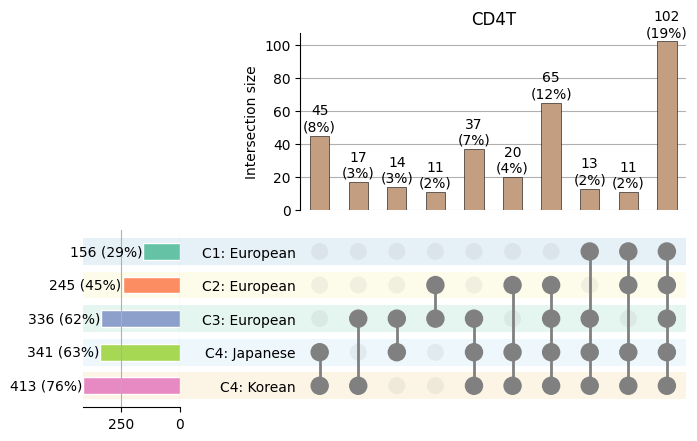

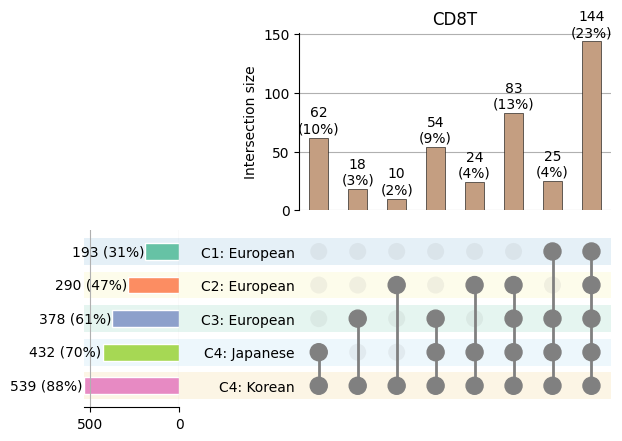

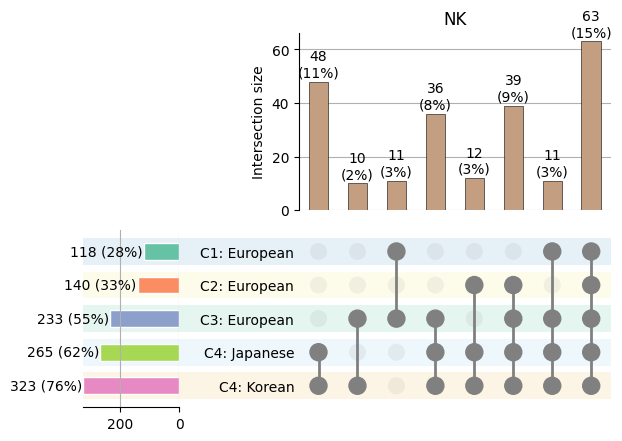

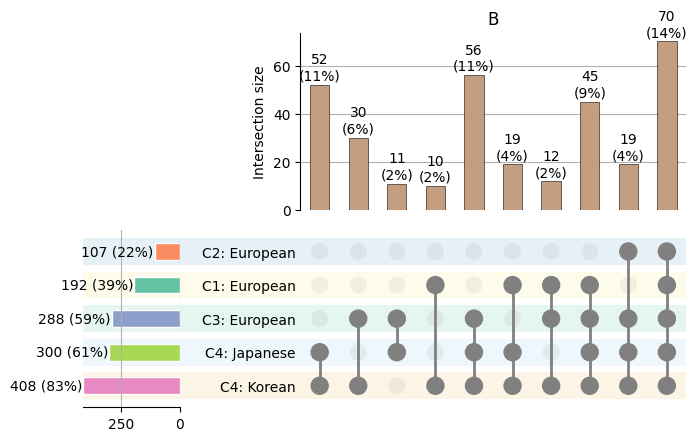

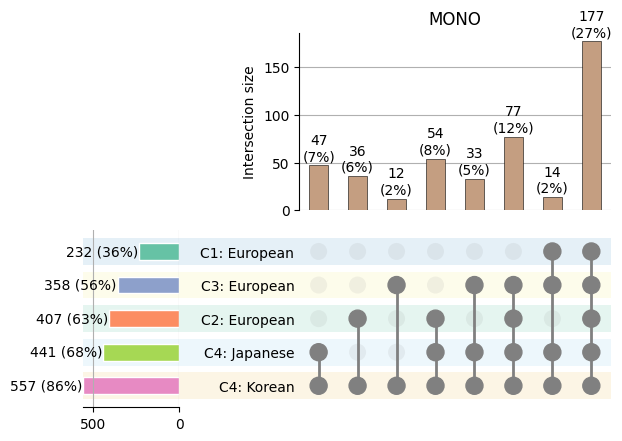

In [35]:
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df
if True:
    # for source
    to_show='source'

    if to_show=='source':
        min_subset_size=10
        min_degree=2
    if to_show=='target':
        min_subset_size=10
        min_degree=2
    if to_show=='edge':
        min_subset_size=100
        min_degree=2


    for cell_type in cell_types:
        nets = nets_all[nets_all['cell_type']==cell_type]
        # edges
        df_dict = nets.groupby(['dataset'])[to_show].apply(list).to_dict()

        interaction_df = create_interaction_df(df_dict)
        interaction_df.columns = interaction_df.columns.map(surrogate_names)
        aa = plot_interactions(interaction_df, min_degree=min_degree, min_subset_size=min_subset_size, color_map=palette_datasets_pretty)
        plt.title(cell_type)

# Overall view

## Heatmap of sig TFs across cell types and cohorts

In [40]:
# - read all stats (with and without significance) and add is_significant to mark the significant ones
type = 'bulk'

stats_all = pd.read_csv(f'../output/tf_activation/stats_all_{type}.csv')

# - add sig signs for e
stats_e = retrieve_sig_stats(type, analysis='european')
tuple_index = stats_e.set_index(['cell_type', 'tf', 'dataset']).index
stats_all = stats_all.set_index(['cell_type', 'tf', 'dataset'])
stats_all['is_significant'] = False
stats_all.loc[tuple_index, 'is_significant'] = True
stats_all.reset_index(inplace=True)

# - add sig signs for a
stats_a = retrieve_sig_stats(type, analysis='asian')
tuple_index = stats_a.set_index(['cell_type', 'tf']).index
stats_all = stats_all.set_index(['cell_type', 'tf'])
stats_all.loc[tuple_index, 'is_significant'] = True
stats_all.reset_index(inplace=True)



stats_all['cell_type'] = pd.Categorical(stats_all['cell_type'], categories=cell_types, ordered=True)
stats_all['dataset'] = pd.Categorical(stats_all['dataset'], categories=datasets_all, ordered=True)


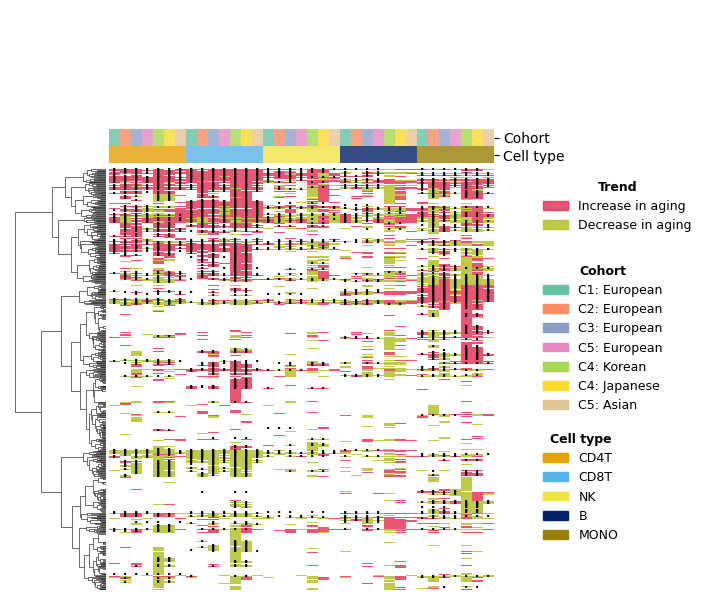

In [41]:
from ciim.src.tf_activity.plots import plot_overall_heatmap

plot_overall_heatmap(stats_all, 
                    sig_dots_y_offset=4, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='dataset', second_col_palette=palette_datasets,
                    bbox_to_anchor_col2=(1.1, .8),
                    figsize=(6, 8),
                    map_names={**{'cell_type':'Cell type', 'dataset': 'Cohort'}, **surrogate_names})
# plt.savefig(f'../output/tf_activation/overall_heatmap_{type}.png', bbox_inches='tight', dpi=300)

## Intersection of races

{'ZNF331', 'BAZ2A', 'IRF1', 'ZBTB1', 'IKZF2', 'STAT3', 'SP100', 'KLF3', 'E2F3', 'CREB3L2', 'JUNB', 'ZNF706', 'KLF2', 'IKZF3', 'KMT2A', 'EEA1', 'DRAP1', 'DDIT3', 'RUNX3', 'RARA', 'ZEB2', 'BPTF', 'STAT1', 'FOSB', 'NME2', 'KLF10', 'HMGA1', 'ZNF101', 'CREBZF', 'MYBL1', 'YBX3', 'IKZF1', 'NR4A2', 'BACH2', 'CREM', 'MYC', 'ELF1', 'IRF9', 'NFATC3', 'STAT5B', 'ZNF207', 'FOXN3', 'PHF19', 'FOXP3', 'SON', 'YY1', 'ZNF292', 'ZNF267', 'ZNF831'}
{'JUND', 'KLF12', 'JUN', 'IKZF2', 'STAT3', 'E2F3', 'ARNTL', 'CREB3L2', 'JAZF1', 'TGIF1', 'HMGN3', 'STAT1', 'FOSB', 'ZNF302', 'NME2', 'ZBTB25', 'SMAD3', 'KLF10', 'CSRNP1', 'ZNF600', 'MTERF4', 'ARHGAP35', 'GFI1', 'ELF1', 'KDM2A', 'NR4A2', 'CXXC5', 'ZBTB16', 'NFKB2', 'ETS1', 'ZNF814', 'KLF7', 'ELK3', 'ZSCAN18', 'ZNF831'}
{'JUND', 'ZNF331', 'DNMT1', 'NFATC2', 'RORA', 'BNC2', 'ATF4', 'CEBPB', 'GTF3A', 'IRF8', 'JUNB', 'XBP1', 'KLF2', 'MAFF', 'BHLHE40', 'AKNA', 'DRAP1', 'BPTF', 'KLF6', 'FOSB', 'FOXP1', 'FOS', 'NME2', 'CSRNP1', 'HMGA1', 'ZNF428', 'NR4A2', 'CEBPD', 'CXX

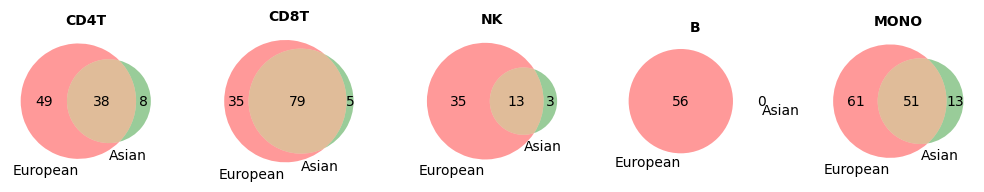

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Collect stats as sets of significant TFs for each analysis and cell type
stats_e = retrieve_sig_stats(type, analysis='european')
stats_a = retrieve_sig_stats(type, analysis='asian')


fig, axes = plt.subplots(1, len(cell_types), figsize=(2 * len(cell_types), 2))

if len(cell_types) == 1:
    axes = [axes]

for ax, cell_type in zip(axes, cell_types):

    set_e = set(stats_e[stats_e['cell_type'] == cell_type]['tf'].unique())
    set_a = set(stats_a[stats_a['cell_type'] == cell_type]['tf'].unique())

    print(set_e-set_a)

    v = venn2([set_e, set_a], set_labels=('European', 'Asian'), ax=ax)
    for text in v.set_labels:
        if text: text.set_fontsize(10)
    for text in v.subset_labels:
        if text: text.set_fontsize(10)
    ax.set_title(cell_type, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Cell type specific plots: explicit dataset stats

In [46]:
type = 'bulk'

array(['data1', 'data7_allTPs_jalil', 'data12', 'data13_Korean',
       'data13_Japanese', 'SLE_Asian_normal', 'SLE_European_normal'],
      dtype=object)

In [44]:
stats_all = pd.read_csv(f'../output/tf_activation/stats_all_{type}.csv')

def subset_func(df1, df2, mode_f=np.intersect1d):
    df_store = []
    for cell_type in df1['cell_type'].unique():
        # - subset
        df1_sub = df1[df1['cell_type'] == cell_type]
        df2_sub = df2[df2['cell_type'] == cell_type]
        # - subset
        tfs = mode_f(df1_sub['tf'].unique(), df2_sub['tf'].unique())
        # - subset
        df1_sub = df1_sub[df1_sub['tf'].isin(tfs)]
        df_store.append(df1_sub)
    df1 = pd.concat(df_store)
    return df1

if False:
    stats_sig_1 = retrieve_sig_stats(type, analysis='european') 
    stats_sig_2 = retrieve_sig_stats(type, analysis='asian')
    stats_sig = subset_func(stats_sig_1, stats_sig_2, mode_f=np.intersect1d)
else:
    stats_sig = retrieve_sig_stats(type, analysis='european')

tupled_index = stats_sig.set_index(['cell_type', 'tf']).index
stats_all = stats_all.set_index(['cell_type', 'tf']).loc[tupled_index].reset_index().drop_duplicates(subset=['cell_type', 'tf', 'dataset'])

# - only keep the consistent ones
# sign_df = stats_all.groupby(['cell_type', 'tf'])['slope'].apply(lambda x: np.sign(x).nunique() == 1)
# tuple_index = sign_df[sign_df].index
# stats_all = stats_all.set_index(['cell_type', 'tf']).loc[tuple_index].reset_index()

In [45]:
stats_sig.drop_duplicates(subset=['cell_type', 'analysis', 'tf']).groupby(['cell_type', 'analysis']).size()
# stats_all[(stats_all['cell_type']=='CD4T') & (stats_all['tf']=='JUN')]

cell_type  analysis
B          european     56
CD4T       european     87
CD8T       european    114
MONO       european    112
NK         european     48
dtype: int64

In [46]:
c_dict = {}
for cell_type in cell_types:
    c_store = []
    for dataset in datasets_all:
        net = net_lambda(dataset, cell_type)
        c = net.groupby('source').size()
        c = c.div(c.max())
        c = c.reset_index(name='centrality')
        c['dataset'] = dataset
        c_store.append(c)
    c = pd.concat(c_store)
    # mean_c.groupby('source')['centrality'].mean().reset_index()
    c['cell_type'] = cell_type
    c_dict[cell_type] = c

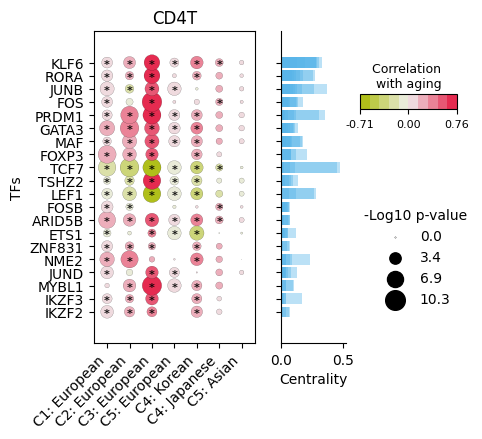

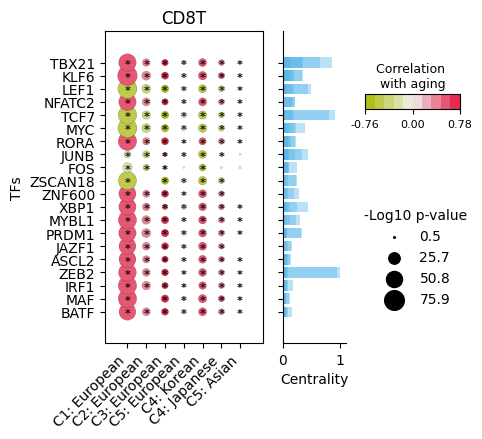

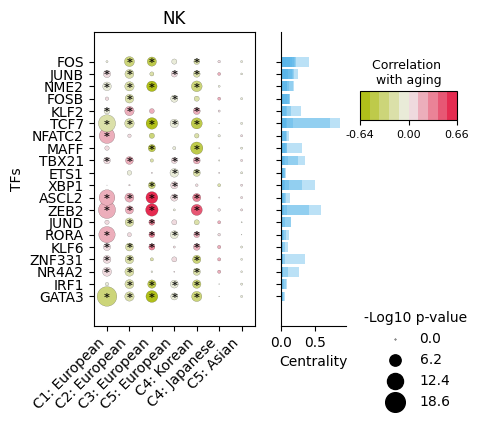

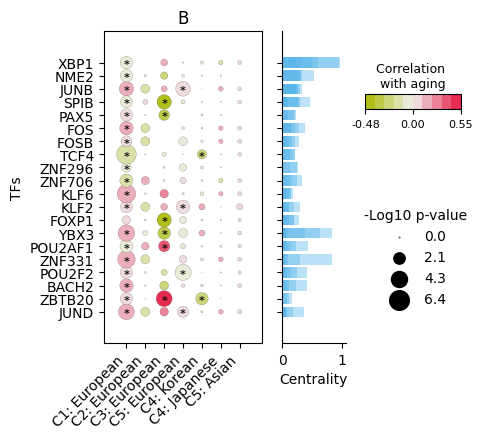

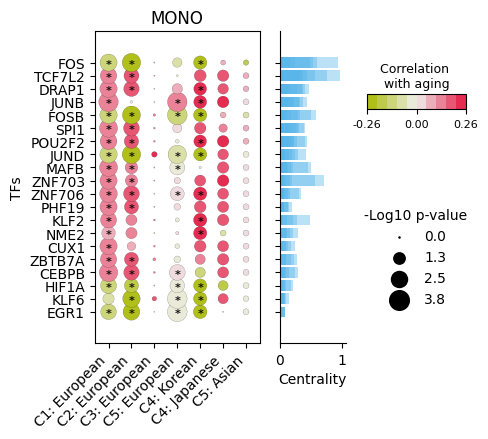

In [47]:
from matplotlib.colors import TwoSlopeNorm
from ciim.src.common import cmap_trend

for i, cell_type in enumerate(cell_types):
    
    # - centrality
    c = c_dict[cell_type]
    c_median = c.groupby(['source'])['centrality'].median().reset_index()

    # - prepare the data for the main plot
    stats_t = stats_all[stats_all['cell_type']==cell_type]
    stats_t = stats_t.merge(c_median, left_on='tf', right_on='source', how='left')
    tfs = stats_t.drop_duplicates(subset=['tf', 'centrality']).sort_values('centrality', ascending=False).head(20)['tf'].unique() # subset to top ones
    df = stats_t[stats_t['tf'].isin(tfs)]
    df = df.sort_values('centrality', ascending=True)
    df['neg_log10_adj_pval'] = -np.log10(df['p_value_adj'])
    df['dataset'] = pd.Categorical(df['dataset'], categories=datasets_all, ordered=True)
    df['dataset'] = df['dataset'].apply(lambda name: surrogate_names.get(name, name))


    # - main plot
    fig, axes = plt.subplots(1, 2, figsize=(5, .15*len(tfs)+1.5), width_ratios=[1, .4] , sharey=True)
    ax = axes[0]
    if cell_type == 'NK':
        size_legend_loc = (1.2, -.3)
        cbar_height='10%'
    else:
        size_legend_loc=(1.2, 0.1)
        cbar_height='5%'
    if df.shape[0]==0:
        continue
    # Ensure 'tf' is a categorical with the desired order
    df['tf'] = pd.Categorical(df['tf'], categories=df['tf'].unique(), ordered=True)
    dotplot(df, 
            x='dataset',
            ax=ax, 
            color_col='slope', 
            size_col='neg_log10_adj_pval', 
            # palette=palette_trend_2, 
            palette=cmap_trend, 
            show_color_legend=True, 
            show_size_legend=True,
            alpha=1,
            size_legend_title='-Log10 p-value',
            color_legend_title='Correlation \nwith aging',
            size_legend_loc=size_legend_loc,
            bbox_to_anchor_cbar=(1.25, -.2, 1, 1),
            cbar_height=cbar_height,
            linewidth=0.1,  
            size_legend_scale = 200/max(df['neg_log10_adj_pval']),
            )
    pval_threshold = 1.4
    x_vals = df['dataset'].astype('category').cat.codes
    y_vals = df['tf'].astype('category').cat.codes
    for i, row in df.iterrows():
        if row['neg_log10_adj_pval'] >= pval_threshold:
            ax.text(x_vals[i], y_vals[i]-.1, '*', ha='center', va='center', alpha=.9, 
                    fontsize=8, weight='bold', color='black', zorder=10)

    ax.margins(x=0.2, y=-0.005*len(tfs)+.2)
    ax.set_ylabel('TFs')
    ax.set_title(cell_type)
    # - centrality
    c = c[c['source'].isin(tfs)]
    # Set the same categorical order as df['tf']
    ordered_tfs = df['tf'].cat.categories  # Get the ordered list from df
    c = c.set_index('source').loc[ordered_tfs].reset_index().rename(columns={'index': 'source'})
    # print(c['source'].nunique())
    ax = axes[1]
    ax.barh(c['source'], c['centrality'], color=colors_blind[1], alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)
    ax.margins(x=0.1)
    ax.set_xlabel('Centrality')
    plt.tight_layout()

## Stats

In [35]:
stats_valid = retrieve_valid_stats(type)

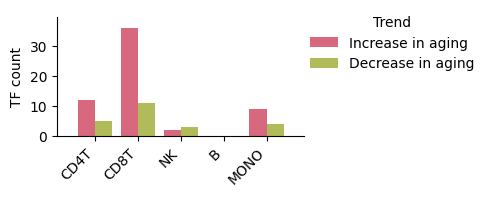

In [37]:
def plot_sig_tfs_stats(df, figsize=(3.5, 2)):
    

    df = df[['tf', 'cell_type', 'trend']]
    df['trend'] = df['trend'].astype(CategoricalDtype(categories=palette_trend_2.keys(), ordered=True))
    df = df[~df.duplicated()].reset_index(drop=True)
    df_counts = df.groupby(['cell_type', 'trend']).size().reset_index(name='Sig. TFs')

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    sns.barplot(data=df_counts, x='cell_type', y='Sig. TFs', alpha=.8, hue='trend', palette=palette_trend_2, ax=ax)
    ax.set_ylabel('TF count')
    ax.set_xlabel('')
    ax.margins(x=0.1, y=0.1)
    ax.legend(loc=(1, 0.5), title='Trend', frameon=False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.xticks(rotation=45, ha='right')
    # plt.suptitle('TFs significantly associated with age', fontsize=12)
    plt.tight_layout()
    # plt.savefig(f'../output/tf_activation/trends.png', dpi=300)
stats_valid['cell_type'] = pd.Categorical(stats_valid['cell_type'], categories=cell_types, ordered=True)
plot_sig_tfs_stats(stats_valid, figsize=(5, 2))

## Identify sig networks

In [34]:
from ciim.src.tf_activity.helper import retrieve_valid_stats
retrieve_valid_stats(type) 

,tf,cell_type,trend
0,ARID5B,CD4T,Increase in aging
2,BATF,CD4T,Increase in aging
4,BCL11B,CD4T,Decrease in aging
6,BHLHE40,CD4T,Increase in aging
8,ELK3,CD4T,Increase in aging
...,...,...,...
154,ASCL2,NK,Increase in aging
156,GATA3,NK,Decrease in aging
158,IRF1,NK,Decrease in aging
160,PRDM1,NK,Increase in aging


In [38]:
from ciim.src.tf_activity.helper import wrapper_extract_sig_network
type = 'bulk'

par = {
    'type': type,    
    'min_degree_network': 5,
    'sig_nets': f'../output/tf_activation/sig_nets_{type}.csv'
}
if True:
    wrapper_extract_sig_network(par)

Number of targets across datasets:
CD4T (186, 4)
CD8T (407, 4)
MONO (326, 4)
NK (46, 4)
   cell_type              trend  counts
0       CD4T  Increase in aging      59
1       CD4T  Decrease in aging      10
2       CD4T       Inconsistent       0
3       CD8T  Increase in aging     209
4       CD8T  Decrease in aging     131
5       CD8T       Inconsistent       0
6       MONO  Increase in aging      33
7       MONO  Decrease in aging       3
8       MONO       Inconsistent       0
9         NK  Increase in aging       6
10        NK  Decrease in aging       4
11        NK       Inconsistent       0


## Network topology

In [16]:
tf_all = np.loadtxt(f'{task_grn_inference_dir}/resources/grn_benchmark/prior/tf_all.csv', dtype=str)

nets = pd.read_csv(f'../output/tf_activation/sig_nets_{type}.csv')

In [68]:
# nets['cell_type'].unique()

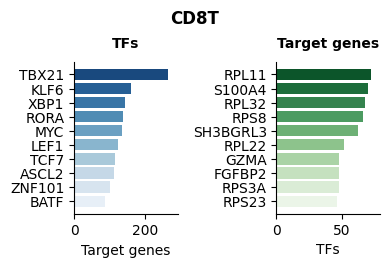

In [17]:
from ciim.src.tf_activity.plots import plot_net_degrees

for cell_type in ['CD8T']:
    net = nets[nets['cell_type'] == cell_type]
    plot_net_degrees(net)
    plt.suptitle(f'{cell_type}', fontsize=12, y=1.05, fontweight='bold')
    

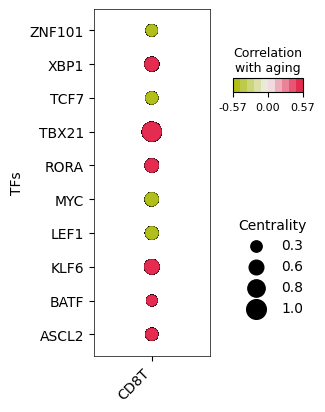

In [18]:
if True:
    from ciim.src.common import cmap_trend
    col = 'source'

    top_tf_n = 10
    top_tfs_df = []

    for cell_type in nets['cell_type'].unique():
        net = nets[nets['cell_type'] == cell_type]
        # Calculate raw out-degree
        out_deg = net.groupby(col).size().reset_index(name='degree')
        out_deg = out_deg.sort_values('degree', ascending=False).head(top_tf_n)

        # Normalize out-degree
        out_deg['degree'] = out_deg['degree'] / out_deg['degree'].max()

        out_deg['cell_type'] = cell_type
        out_deg = out_deg.merge(net[['cell_type', col]], on=['cell_type', col], how='left')

        top_tfs_df.append(out_deg)

    # Combine
    top_tfs_df = pd.concat(top_tfs_df)
    top_tfs_df = top_tfs_df.merge(stats_valid[['cell_type', 'tf', 'slope']], left_on=['cell_type', 'source'], right_on=['cell_type', 'tf'], how='left')
    top_tfs_df = top_tfs_df.rename(columns={col: 'target', 'degree': 'centrality'})
    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(1.5, 4.5))
    
    dotplot(
        top_tfs_df,
        ax=ax,
        color_col='slope',
        size_col='centrality',
        y='target',
        color_legend_title='Correlation\nwith aging',
        size_legend_title='Centrality',
        palette=cmap_trend,
        sizes=(20, 200),
        size_legend_loc=(1.2, .1),
        color_legend_loc=(1, .7),
        linewidth=0.1,
        size_legend_scale=200,
        alpha=0.8,
    )
    ax.set_ylabel('TFs')
    ax.margins(x=0.3, y=0.07)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)  # Set the border thickness to 0.5


## Shared sig TFs between cell types

In [121]:
stats_sig = retrieve_sig_stats(type, analysis='european')

['CD8T', 'CD4T', 'MONO', 'NK']


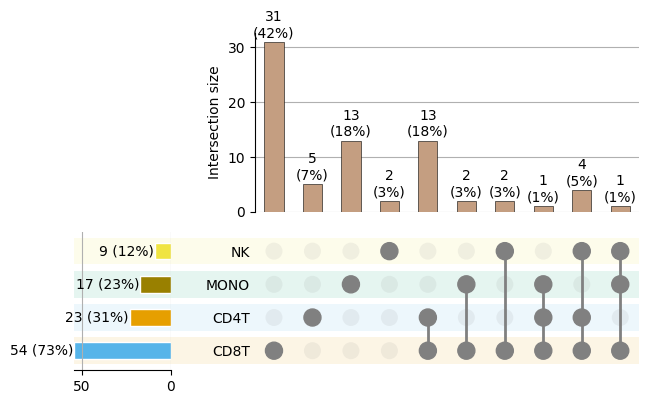

In [122]:
sys.path.append('../../')
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df

df_dict = stats_sig.groupby(['cell_type'])['tf'].apply(list).to_dict()
interaction_main_df = create_interaction_df(df_dict)
aa = plot_interactions(interaction_main_df, min_subset_size=1, color_map=palette_cell_types)
# plt.savefig(f'../output/tf_activation/interactions.png', dpi=300)
# plt.title('', pad=40)

In [123]:
from ciim.src.common import cmap_trend

from ciim.src.utils.plots import dotplot

df = interaction_main_df.copy()
# if type == 'sc':
#     shared_cell_types = ['CD8T', 'NK']
# else:
#     shared_cell_types = ['CD4T', 'CD8T', 'NK', 'MONO']
# df = df[shared_cell_types]

degree3_tfs = df[df.sum(axis=1)==3].index
print(degree3_tfs)
selected_tfs = degree3_tfs

Index(['CEBPB', 'BATF', 'TCF7', 'DRAP1', 'PRDM1', 'GATA3'], dtype='object')


In [138]:
# stats_all = pd.read_csv(f'../output/tf_activation/stats_all_{type}.csv')
# stats_all = stats_all[stats_all['tf'].isin(selected_tfs)]
# stats_all = stats_all[stats_all['trend'] != 'Inconsistent'].drop('trend', axis=1)



stats_tfs_mean = stats_sig[['cell_type', 'tf', 'slope', 'meta_p_adj', 'trend']].groupby(['cell_type', 'tf'], as_index=False).mean(numeric_only=True)
stats_tfs_mean = stats_tfs_mean[stats_tfs_mean['tf'].isin(selected_tfs)]

Text(0.5, 1.1, 'Common sig. TFs ')

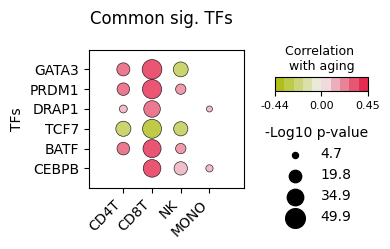

In [143]:
fig, ax = plt.subplots(1, 1, figsize=(2, len(selected_tfs)*.3), 
                        #  gridspec_kw={'width_ratios': [.2, .2]}, 
                         sharey=True)# - plot TF activation stats
df = stats_tfs_mean
df['tf'] = pd.Categorical(df['tf'], categories=selected_tfs, ordered=True)
df = df.sort_values('tf')
df['cell_type'] = df['cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO'], ordered=True))
df['neg_log10_adj_pval'] = -np.log10(df['meta_p_adj'])
df['slope'] = df['slope'].astype(float)


dotplot(df, ax, 
        color_col='slope', 
        size_col='neg_log10_adj_pval', 
        # palette=palette_trend_2, 
        palette=cmap_trend, 
        show_color_legend=True, 
        show_size_legend=True,
        alpha=.8,
        size_legend_title='-Log10 p-value',
        color_legend_title='Correlation \nwith aging',
        size_legend_loc=(1.1, -.3),
        color_legend_loc=(1.05, 0.6),
        cbar_height='10%',
        size_legend_scale = 200/max(df['neg_log10_adj_pval'])
        )
ax.margins(x=0.4, y=0.2)
ax.set_ylabel('TFs')
# plt.savefig(f'../output/tf_activation/degree3_tfs.png', dpi=300)
plt.suptitle('Common sig. TFs ', fontsize=12, y=1.1)

## Shared sig TFs between CD8T and CD4T

(13,)


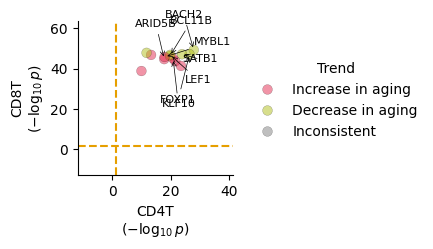

In [157]:
from ciim.src.tf_activity.plots import plot_joint_scatter

interaction_main_ts_df = interaction_main_df[['CD4T', 'CD8T']]
sig_tfs_ts = interaction_main_ts_df[interaction_main_ts_df.sum(axis=1)==2].index
sig_tfs_ts = np.setdiff1d(sig_tfs_ts, degree3_tfs)
print(sig_tfs_ts.shape)
# Get significant TFs for CD4T and CD8T cells
df = stats_sig[stats_sig['tf'].isin(sig_tfs_ts)].drop_duplicates(subset=['cell_type', 'tf'])
df['neg_log10_adj_pval'] = -np.log10(df['meta_p_adj'])

fig, ax = plt.subplots(1, 1, figsize=(2, 2))
plot_joint_scatter(df, vars=['CD4T', 'CD8T'], annotate=True, ax=ax)
ax.margins(x=0.5, y=0.3)

## Unique TFs

In [99]:
def get_unique_central_tfs(df, cell_type, n=20):
    df = df[df['cell_type']==cell_type]
    df = df[~df['tf'].isin(degree3_tfs)]
    net = consensus_nets_dict[cell_type]
    tfs = net.groupby(['source']).size().sort_values(ascending=False).head(n).index.to_numpy()
    return tfs
def get_unique_sig_tfs(df_all, cell_type, n=20):
    other_tfs = df_all[df_all['cell_type']!=cell_type]['tf'].unique()
    df = df_all[df_all['cell_type']==cell_type]
    this_cell_tfs = df['tf'].unique()
    unique_tfs = np.setdiff1d(this_cell_tfs, other_tfs)
    df = df[df['tf'].isin(unique_tfs)]
    tfs = df.sort_values('meta_p_adj', ascending=True).head(n)['tf'].to_numpy()
    return np.unique(tfs)

## GSEA

In [3]:
from ciim.src.tf_activity.helper import pathway_analysis_wrapper
type = 'bulk'

stats_sig = retrieve_sig_stats(type, analysis='european')
pathway_scores = pathway_analysis_wrapper(stats_sig)
pathway_scores["neg_log10_adj_pval"] = -np.log10(pathway_scores["Adjusted P-value"])

cell_type: CD4T, trend: Increase in aging, n tfs: 16
(6, 10)
cell_type: CD4T, trend: Decrease in aging, n tfs: 7
(3, 10)
cell_type: CD8T, trend: Increase in aging, n tfs: 43
(8, 10)
cell_type: CD8T, trend: Decrease in aging, n tfs: 11
(3, 10)
cell_type: NK, trend: Increase in aging, n tfs: 4
(6, 10)
cell_type: NK, trend: Decrease in aging, n tfs: 5
(15, 10)
cell_type: MONO, trend: Increase in aging, n tfs: 11
(4, 10)
cell_type: MONO, trend: Decrease in aging, n tfs: 6
(1, 10)


In [164]:
# pathway_scores

TypeError: bad operand type for abs(): 'str'

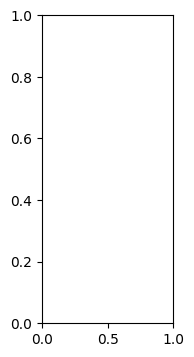

In [4]:
from ciim.src.utils.plots import dotplot

# Create figure
fig, ax = plt.subplots(figsize=(1.7, 4))
dotplot(pathway_scores, ax, color_col='trend', size_col='neg_log10_adj_pval', 
            x='cell_type', 
            y='Term', 
            palette=palette_trend_2, sizes=(50, 250),
            show_color_legend=True, 
            show_size_legend=True,
            size_legend_title='Significance',
            color_legend_title='Pathway activity',
            size_legend_loc=(1.25, 0.35),
            color_legend_loc=(1.02, 0.75),
            y_label='',
            alpha=0.5)
# ax.grid(True, linestyle="--", alpha=0.5)
# ax.spines[['right']].set_visible(False)
ax.margins(x=.3, y=.1)
# plt.title("Canonical Hallmarks", pad=20)
plt.tight_layout()
plt.savefig(f'../output/tf_activation/pathways.png', dpi=300)

In [ ]:

def dotplot_2(df, ax, color_col='trend', size_col='neg_log10_adj_pval', 
            x='cell_type', 
            y='tf', 
            palette=None, sizes=(20, 200),
            show_color_legend=True, 
            show_size_legend=True,
            y_label="Transcription Factor",
            size_legend_title='-log10(p-value)',
            color_legend_title='Trend',
            size_legend_loc=(1.1, 0.1),
            color_legend_loc=(1.1, 0.7),
            bbox_to_anchor_cbar=(0.8, -.2, 1, 1),
            alpha=0.5,
            linewidth=0.5,
            cbar_height='4%',
            size_legend_scale=10,):
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    from matplotlib.colors import TwoSlopeNorm


    vmin = df[color_col].min()
    vmax = df[color_col].max()
    abs_max = max(abs(vmin), abs(vmax))
    norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

    # Get numeric positions for x/y if categorical
    x_vals = df[x].astype('category').cat.codes
    y_vals = df[y].astype('category').cat.codes

    # Store tick labels
    x_labels = df[x].astype('category').cat.categories
    y_labels = df[y].astype('category').cat.categories

    # Map slope to color using manual colormap
    cmap = plt.get_cmap(palette if palette else 'RdBu_r')
    df['mapped_color'] = df[color_col].apply(lambda val: cmap(norm(val)))

    # Map p-values to size
    df['mapped_size'] = df[size_col] * size_legend_scale

    # Plot
    ax.scatter(x_vals, y_vals, 
               c=df['mapped_color'], 
               s=df['mapped_size'], 
               edgecolor='black', 
               linewidth=linewidth, 
               alpha=alpha)

    # Set axis ticks and labels
    ax.set_xticks(np.unique(x_vals))
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_yticks(np.unique(y_vals))
    ax.set_yticklabels(y_labels)

    ax.set_xlabel('')
    ax.set_ylabel(y_label)
    ax.margins(x=.1, y=.1)
    # Create Legends
    if show_size_legend:
        size_legend_values = np.linspace(df[size_col].min() , df[size_col].max(), num=4)
        size_legend_handles = [plt.scatter([], [], s=s * size_legend_scale, color="black", label=f"{s:.1f}") for s in size_legend_values]
        size_legend_handle = plt.legend(handles=size_legend_handles, title=size_legend_title, loc=size_legend_loc, frameon=False)
    
    if show_color_legend and isinstance(df[color_col].dtype, pd.CategoricalDtype):
        color_legend = [
            Line2D([0], [0], marker='o', color='none', markerfacecolor=color,
                markersize=10, label=name, alpha=alpha) 
            for name, color in palette.items()
        ]
        color_legend_handle = plt.legend(
            handles=color_legend, 
            title=color_legend_title, 
            loc=color_legend_loc, 
            frameon=False
        )
    if show_color_legend and not isinstance(df[color_col].dtype, pd.CategoricalDtype):
        # vmin = df[color_col].min()
        # vmax = df[color_col].max()
        # abs_max = max(vmin, vmax)
        if vmin < 0 and vmax > 0:
            norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
        else:
            norm = plt.Normalize(vmin=vmin, vmax=vmax) 
        sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
        sm.set_array([])

        # Create the colorbar
        axins = inset_axes(
            ax,
            width="60%",
            height=cbar_height,
            loc='upper right',
            bbox_to_anchor=bbox_to_anchor_cbar,
            bbox_transform=ax.transAxes,
            borderpad=0
        )

        cbar = plt.colorbar(sm, cax=axins, orientation='horizontal')

        # Force ticks to show symmetric values or desired range
        tick_values = [vmin, 0, vmax ]  # or manually: [-1, -0.5, 0, 0.5, 1]
        cbar.set_ticks(tick_values)
        cbar.ax.set_xticklabels([f"{x:.2f}" for x in tick_values])

        cbar.ax.tick_params(labelsize=8, direction='out')
        cbar.ax.set_title(color_legend_title, fontsize=9, pad=5)
    # if show_color_legend:
    # plt.gca().add_artist(size_legend_handle)
# pathway_scores['cell_type'] = pd.Categorical(pathway_scores['cell_type'], categories=cell_types, ordered=True)
# df = pathway_scores
# # Create figure
# size_col = 'neg_log10_adj_pval'
# size_legend_scale = 10
# size_legend_loc = (1.2, 0.1)
# size_legend_title = '-Log10 p-value'
# color_col = 'trend'
# color_legend = 'Trend'
# color_legend_loc = (1.2, 0.5)
# fig, ax = plt.subplots(figsize=(1.7, 5))
# sns.scatterplot(data=df, x='cell_type', y='Term', size='neg_log10_adj_pval', hue='trend', palette=palette_trend_2, ax=ax, legend=False, sizes=(20, 200), alpha=0.8)
# # ax.grid(True, linestyle="--", alpha=0.5)
# # ax.spines[['right']].set_visible(False)
# ax.margins(x=.3, y=.05)
# ax.set_xticklabels(df['cell_type'].astype('category').cat.categories, rotation=45, ha='right')
# ax.set_ylabel('')
# ax.set_xlabel('')

# # Create Legends
# size_legend_values = np.linspace(df[size_col].min() , df[size_col].max(), num=4)
# size_legend_handles = [plt.scatter([], [], s=s * size_legend_scale, color="black", label=f"{s:.1f}") for s in size_legend_values]
# size_legend_handle = plt.legend(handles=size_legend_handles, title=size_legend_title, loc=size_legend_loc, frameon=False)

# color_legend = [
#     Line2D([0], [0], marker='o', color='none', markerfacecolor=color,
#         markersize=10, label=name, alpha=alpha) 
#     for name, color in palette_trend_2.items()
# ]
# color_legend_handle = plt.legend(
#     handles=color_legend, 
#     title=color_legend_title, 
#     loc=color_legend_loc, 
#     frameon=False
# )

In [20]:
# - the term with bifurcation enrichment
pathway_scores_t = pathway_scores[(pathway_scores['Term'] == 'TNF-alpha Signaling via NF-kB') & (pathway_scores['cell_type'] == 'CD8T')]
df = pathway_scores_t.groupby(['trend'])['Genes'].apply(lambda x: ', '.join(x)).reset_index(name='Genes').set_index('trend')
increased_tfs = df.loc['Increase in aging', :].values

decreased_tfs = df.loc['Decrease in aging', :].values

';'.join(increased_tfs[0].split(';'))  # original

evey_n_words = 5
pp_nfkb_cd8t = {'Increase in aging': ', \n'.join([
                    ', '.join(increased_tfs[0].split(';')[i:i+evey_n_words])
                    for i in range(0, len(increased_tfs[0].split(';')), evey_n_words)
                    ]), 
                'Decrease in aging': ', '.join(decreased_tfs[0].split(';'))}

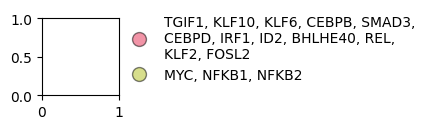

In [ ]:
palette = palette_trend_2
from matplotlib.lines import Line2D
alpha = .5

plt.figure(figsize=(1, 1))
color_legend = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor=color,
            markersize=10, label=pp_nfkb_cd8t[name], alpha=alpha) 
        for name, color in palette.items()
    ]
color_legend_handle = plt.legend(
    handles=color_legend, 
    title='', 
    loc=(1, .1), 
    frameon=False
)


# Minor cell types

## Heatmap

In [4]:
from ciim.src.common import mapping_minor_2_major
# - get the stats for bulk of both gender
stats_store = []
for type in ['bulk', 'bulk_minor']:
    stats_tf = pd.read_csv(f'../output/tf_activation/stats_tfs_{type}.csv')
    stats_tf = stats_tf[(stats_tf['condition']=='healthy')] 
    stats_tf = filter_for_consistent_trends(stats_tf) # change this to include inconsistent ones
    # - add valid cases
    stats_valid = retrieve_sig_stats(type, analysis='european').drop_duplicates(subset=['cell_type', 'tf'])
    stats_tf['is_significant'] = False
    stats_tf['is_significant'] = (stats_tf['tf'].isin(stats_valid['tf'])) & (stats_tf['cell_type'].isin(stats_valid['cell_type']))
    stats_tf['major_cell_type'] = stats_tf['cell_type'].apply(lambda x: mapping_minor_2_major.get(x, x))
    stats_store.append(stats_tf)
stats_all_combined = pd.concat(stats_store, axis=0)[['major_cell_type', 'cell_type', 'tf', 'slope', 'is_significant']].drop_duplicates(subset=['cell_type', 'tf'])

# - plot
stats_all_combined['major_cell_type'] = stats_all_combined['major_cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO', 'B'], ordered=True))


In [5]:
ordered_cell_names = ['CD4T',
                    'Tcm_Naive_CD4',
                    'Tem_Effector_CD4',
                    
                    'CD8T',
                    'Tem_Trm_CD8',
                    'Tem_Temra_CD8',
                    'Tcm_Naive_CD8',
                    'MAIT',

                    'NK',
                    'CD16_NK',
                    'MONO',
                    'Classic_MONO',
                    'NonClassic_MONO',
                    'B',
                    'Memory_B',
                    'Naive_B',
                    ]
stats_all_combined['cell_type'] = pd.Categorical(stats_all_combined['cell_type'], categories=ordered_cell_names, ordered=True)

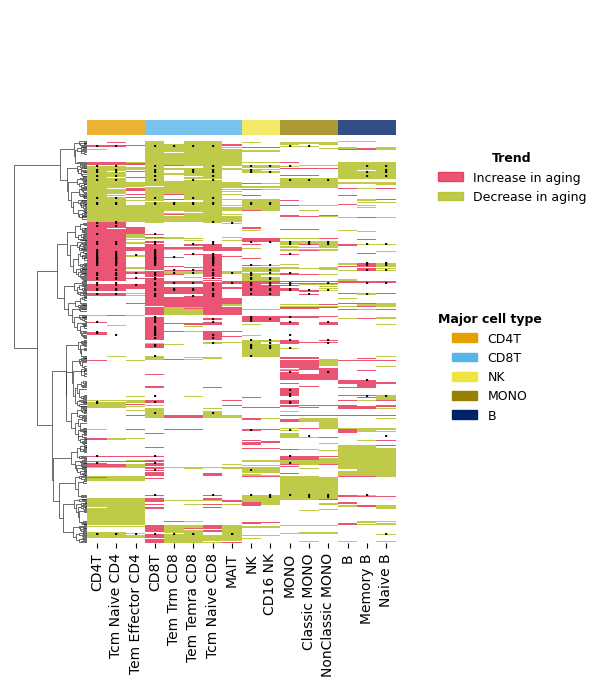

In [11]:
from ciim.src.tf_activity.plots import heamap_plot_minor_cell_types
heamap_plot_minor_cell_types(stats_all_combined, palette=palette_cell_types, figsize=(5, 7), sig_dots_y_offset=3, map_names={'cell_type':'Sub type', 'major_cell_type':'Major cell type'})

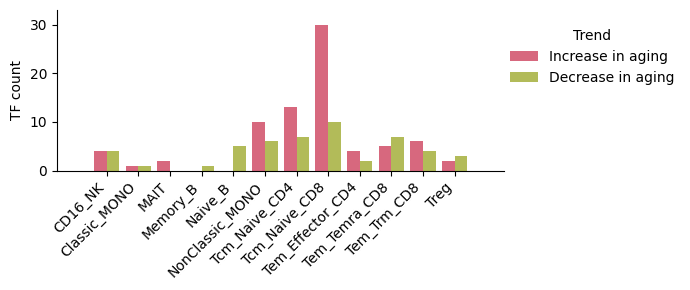

In [20]:
stats_valid = retrieve_sig_stats(type='bulk_minor', analysis='european').drop_duplicates(subset=['cell_type', 'tf'])
plot_sig_tfs_stats(stats_valid, figsize=(7, 3))

## Cell type proportions

In [91]:
obs_dict = {dataset:ad.read_h5ad(f'/vol/projects/jnourisa/datasets/{dataset}_sc.h5ad', backed='r').obs for dataset in datasets}

## TF activity

In [92]:
type = 'bulk_minor'
stats_minor = pd.read_csv(f'../output/tf_activation/stats_all_{type}.csv')
stats_minor_sig = retrieve_valid_stats(type)
stats_minor_sig.head()

,tf,p_value,slope,dataset,cell_type,age_group,condition,slope_disease,values_case,values_control,adj_p_value,meta_p,meta_p_adj,neg_log10_adj_pval,trend,analysis,p_value_adj
11556,ANXA1,5.466096e-11,0.359625,data7_allTPs_jalil,Tcm_Naive_CD4,NaN,NaN,NaN,NaN,NaN,NaN,5.466096e-11,1.610001e-09,8.793174,Increase in aging,validation,NaN
11558,ARID5B,7.798596e-06,0.249681,data7_allTPs_jalil,Tcm_Naive_CD4,NaN,NaN,NaN,NaN,NaN,NaN,7.798596e-06,2.091442e-05,4.679554,Increase in aging,validation,NaN
11559,BACH2,1.640360e-08,-0.312371,data7_allTPs_jalil,Tcm_Naive_CD4,NaN,NaN,NaN,NaN,NaN,NaN,1.640360e-08,1.209766e-07,6.917299,Decrease in aging,validation,NaN
11560,BATF,1.756890e-11,0.368155,data7_allTPs_jalil,Tcm_Naive_CD4,NaN,NaN,NaN,NaN,NaN,NaN,7.580904e-07,3.194810e-06,5.495555,Increase in aging,validation,NaN
11562,BCL11B,3.421349e-04,-0.201148,data7_allTPs_jalil,Tcm_Naive_CD4,NaN,NaN,NaN,NaN,NaN,NaN,3.421349e-04,6.728652e-04,3.172072,Decrease in aging,validation,NaN


## Low-dimensional plot

In [93]:
# - 
sig_tf_size = stats_minor_sig[['cell_type', 'tf']].groupby('cell_type').size().reset_index(name='sig_tfs').rename({'cell_type': 'Sub_CT'}, axis=1)
sig_tf_size

,Sub_CT,sig_tfs
0,CD16_NK,7
1,Tcm_Naive_CD4,44
2,Tcm_Naive_CD8,50
3,Tem_Trm_CD8,1


In [94]:
if False:
    !mkdir ../output/tf_activation/umap/
    adata = ad.read_h5ad('/vol/projects/jnourisa/datasets/data1_bulk_minor.h5ad')
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    sc.pp.pca(adata, use_highly_variable=True)  
    sc.pp.neighbors(adata, n_neighbors=15)  
    sc.tl.umap(adata)  
    adata.write('../output/tf_activation/umap/data_bulk_minor.h5ad')
else:
    adata = ad.read_h5ad('../output/tf_activation/umap/data_bulk_minor.h5ad')
adata.obs = adata.obs.merge(sig_tf_size, on='Sub_CT', how='left')
adata.obs['sig_tfs'] = adata.obs['sig_tfs'].fillna(0).astype(int)
adata = adata[~adata.obs['Sub_CT'].isna(), :]

In [95]:
# adata.obs['Major_CT'] = adata.obs['Major_CT'].astype(str)
adata.obs['Major_CT'].unique()

['B', 'NK', 'MONO', 'CD8T', 'CD4T']
Categories (5, object): ['B', 'CD4T', 'CD8T', 'MONO', 'NK']

In [ ]:
# - plot the umap of #sig tfs per subtype
from ciim.src.utils.plots import plot_umap

for cell_type in ['CD8T', 'CD4T', 'NK', 'MONO']:
        adata_cell = adata[adata.obs['Major_CT'].isin([cell_type])]
        adata_cell.obs['Sub_CT'] = adata_cell.obs['Sub_CT'].astype(str)
        adata_cell = adata_cell[~adata_cell.obs['Sub_CT'].isna(), :]
        adata_cell = adata_cell[~adata_cell.obs['age'].isna(), :]
        sorted_subtypes = mapping_major_2_minor[cell_type]
        # - sanity check 
        # print([c for c in sorted_subtypes if c not in adata_cell.obs['Sub_CT'].unique()])
        # aaa
        diff = np.setdiff1d(adata_cell.obs['Sub_CT'].unique(), sorted_subtypes)
        if diff.shape[0]>0:
                print(diff)
        # - plot the umap of #sig tfs per subtype  
        
        palette={name: value for name, value in zip(sorted(sorted_subtypes), colors_blind)}
        print(palette)
        fig, ax = plt.subplots(1, 1, figsize=(6, 3))
        # ax = axes[0]
        adata_cell.obs['Sub_CT'] = adata_cell.obs['Sub_CT'].astype(CategoricalDtype(categories=sorted_subtypes, ordered=True))
        print(adata_cell.obs['Sub_CT'].unique())
        plot_umap(adata_cell, color='Sub_CT', ax=ax, s=1, X_label='X_pca', alpha=.9, sort_colors=False,
                bbox_to_anchor=(.9,.1), palette=palette,
                margins=dict(x=.1, y=.1), 
                )  
        ax = axes[1]
        groups = adata_cell.obs['sig_tfs'].unique()
        plot_umap(adata_cell, color='sig_tfs', ax=ax, s=1, X_label='X_pca', alpha=.9, 
                bbox_to_anchor=(.9,.1), 
                margins=dict(x=.1, y=.1), 
                palette={name: value for name, value in zip(sorted(groups), sns.color_palette("viridis", n_colors=len(groups)))},
                legend_title='TFs count',
                )  

        plt.suptitle(f'TFs significantly associated with age ({cell_type})', fontsize=12)
        plt.tight_layout()


AssertionError: Don’t call _normalize_index with non-categorical/string names

# STD

In [ ]:
def determine_std(adata):
    # Ensure .X is dense
    if isinstance(adata.X, np.ndarray):
        X_dense = adata.X
    elif hasattr(adata.X, "todense"):
        X_dense = adata.X.todense().A
    else:
        raise TypeError("Unexpected type for adata.X: {}".format(type(adata.X)))

    # Create DataFrame
    df = pd.DataFrame(X_dense, index=adata.obs.index, columns=adata.var_names)
    genes = df.columns

    # Add metadata
    df["age"] = adata.obs["age"].astype(str)
    df["donor_id"] = adata.obs["donor_id"].astype(str)
    df["cell_type"] = adata.obs["cell_type"].astype(str)

    # Compute standard deviation
    std_df = df.groupby(['cell_type', "donor_id", 'age']).std()
    std_adata = sc.AnnData(std_df.values)

    # Reconstruct obs
    std_adata.obs = std_df.reset_index()[['cell_type', "donor_id", 'age']]

    # Prepare metadata from adata.obs with only unique mappings
    group_cols = ['cell_type', 'donor_id', 'age']
    unique_cols = [col for col in adata.obs.columns if col not in group_cols]
    meta_df = adata.obs.copy()
    meta_df[group_cols] = meta_df[group_cols].astype(str)  # Ensure dtype consistency
    meta_df = meta_df[group_cols + unique_cols].drop_duplicates(subset=group_cols)

    std_adata.obs[group_cols] = std_adata.obs[group_cols].astype(str)  # Also convert here
    std_adata.obs = std_adata.obs.merge(meta_df, on=group_cols, how='left')

    # Final cleanup
    std_adata.obs['age'] = pd.to_numeric(std_adata.obs['age'], errors='coerce')
    std_adata.var = pd.DataFrame(index=genes)
    std_adata.X = np.nan_to_num(std_adata.X, nan=0)

    return std_adata
# for dataset in datasets_all:
#     adata = adata_lambda(dataset, type='sc')
#     adata_std = determine_std(adata)
#     aaa
# tf_acts_std = determine_std(tf_acts)

In [ ]:

# --------- load data
print('Loading data...')
type = 'sc'
adata_dict = {dataset: adata_lambda(dataset, type) for dataset in ['data1']}

# - calculate tf activity for all datasets
print('Calculating TF activity...')
stats_store = []
for cell_type in tqdm(cell_types, desc='cell types'):
    # ----------- calculate tf activity for all datasets
    for dataset in datasets:
        adata = adata_dict[dataset][adata_dict[dataset].obs['cell_type']==cell_type]
        net = net_lambda(dataset, cell_type)

        if adata.shape[0] < 10:
            continue
        tf_acts = calculate_tf_activity(adata, net)
        
        tf_acts = tf_acts[tf_acts.obs['age'].isna()==False] # there is a bug in the code that causes age to be NaN
        # print(cell_type, tf_acts.shape)
        write_tf_acts(tf_acts, dataset, cell_type, type, tf_acts_dir)

        if type == 'sc':
            tf_acts = determine_std(tf_acts)
            write_tf_acts(tf_acts, dataset, cell_type, 'std', tf_acts_dir)



{'Bulk': 'gray', 'STD': 'lightblue'}


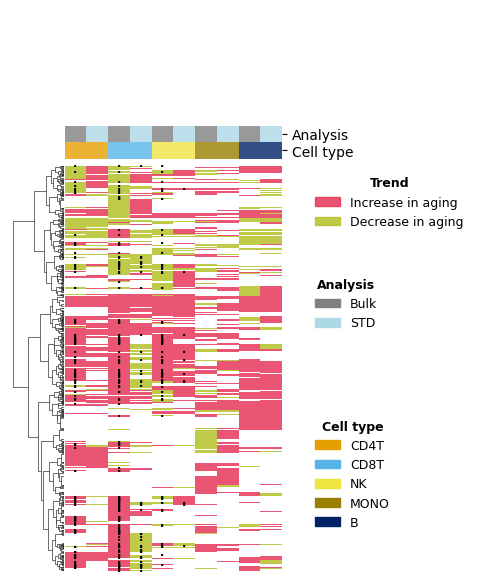

In [15]:
# - get the stats for bulk of bulk and sc
stats_store = []
for type in ['bulk', 'sc']:
    stats_tf = pd.read_csv(f'../output/tf_activation/stats_tfs_{type}.csv')
    stats_tf = stats_tf[(stats_tf['dataset'].isin(datasets_healthy))] 
    stats_tf = filter_for_consistent_trends(stats_tf) # change this to include inconsistent ones
    # - add valid cases
    stats_valid = retrieve_valid_stats(type)
    stats_tf['is_significant'] = False
    stats_tf['is_significant'] = (stats_tf['tf'].isin(stats_valid['tf'])) & (stats_tf['cell_type'].isin(stats_valid['cell_type']))
    
    stats_tf['type'] = type
    stats_store.append(stats_tf)
stats_all_combined = pd.concat(stats_store, axis=0)[['cell_type', 'tf', 'slope', 'type', 'is_significant']].drop_duplicates(subset=['cell_type', 'tf', 'type', 'is_significant'])

# - plot
stats_all_combined['type'] = stats_all_combined['type'].map({'bulk': 'Bulk', 'sc': 'STD'}).astype(CategoricalDtype(categories=['Bulk', 'STD'], ordered=True))
stats_all_combined['cell_type'] = stats_all_combined['cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO', 'B'], ordered=True))

from ciim.src.tf_activity.plots import plot_overall_heatmap

plot_overall_heatmap(stats_all_combined, 
                    sig_dots_y_offset=5, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='type', second_col_palette={'Bulk': 'gray', 'STD': 'lightblue'},
                    figsize=(4, 7),
                    map_names={'cell_type':'Cell type', 'type': 'Analysis'})

In [73]:
cell_type = 'CD8T'

stats_valid_store = []
for type in ['bulk', 'sc']:
    stats_valid = retrieve_valid_stats(type)
    stats_valid = stats_valid[stats_valid['cell_type'].isin([cell_type])]

    nets = pd.read_csv(f'../output/tf_activation/sig_nets_{type}.csv')
    nets = nets[nets['cell_type'].isin([cell_type])]
    central_tfs = nets.groupby(['source']).size().sort_values(ascending=False).head(40).index.to_numpy()
    stats_valid = stats_valid[stats_valid['tf'].isin(central_tfs)]
    # stats_valid = stats_valid.sort_values('meta_p_adj', ascending=True).head(30)
    stats_valid['type'] = type
    stats_valid['cell_type'] = cell_type
    stats_valid_store.append(stats_valid)
stats_valid_all = pd.concat(stats_valid_store, axis=0)
stats_valid_all['neg_log10_adj_pval'] = -np.log10(stats_valid_all['meta_p_adj'])
stats_valid_all['type'] = stats_valid_all['type'].map({'bulk': 'Bulk', 'sc': 'STD'}).astype(CategoricalDtype(categories=['Bulk', 'STD'], ordered=True))


In [74]:
df_common = stats_valid_all.groupby(['cell_type', 'tf']).size()
tuple_index = df_common[df_common==2].index
stats_valid_all = stats_valid_all.set_index(['cell_type', 'tf']).loc[tuple_index].reset_index()

In [54]:
'GATA3' in stats_valid_all['tf'].unique()

False

In [79]:
stats_valid_all['tf'].unique()

array(['RPL35', 'RPL6', 'RPS10', 'RPS4X', 'SATB1', 'TBX21', 'TCF7',
       'TPI1', 'UBB', 'UQCRB', 'XBP1', 'YWHAZ', 'ZBTB38', 'ZEB2',
       'ZNF101', 'ZNF600'], dtype=object)

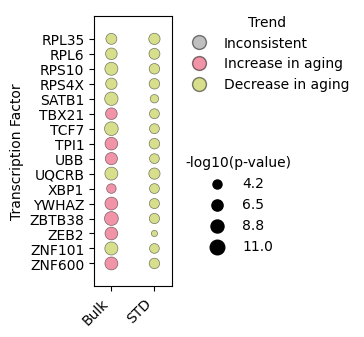

In [77]:
fig, ax = plt.subplots(1, 1, figsize=(1, 3.5))
dotplot(stats_valid_all, ax=ax,
        x='type', y='tf', color_col='trend', size_col='neg_log10_adj_pval', 
        palette=palette_trend, sizes=(20, 100), alpha=.5)
ax.margins(x=0.4, y=0.1)

In [ ]:
read_tf_acts

# Gender


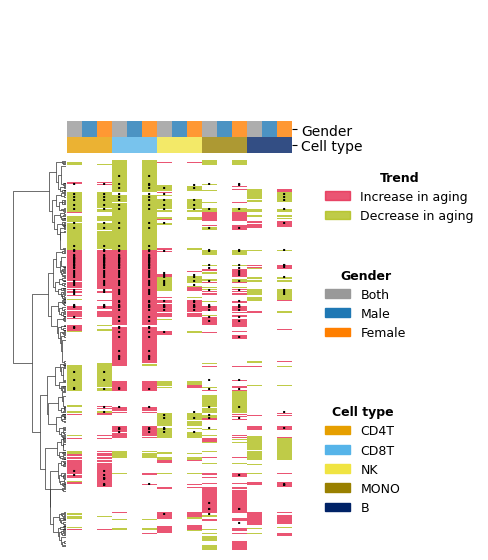

In [21]:
# - get the stats for bulk of both gender
stats_store = []
for type in ['bulk', 'bulk_M', 'bulk_F']:
    stats_tf = pd.read_csv(f'../output/tf_activation/stats_tfs_{type}.csv')
    stats_tf = stats_tf[(stats_tf['condition']=='healthy')] 
    stats_tf = filter_for_consistent_trends(stats_tf) # change this to include inconsistent ones
    # - add valid cases
    stats_valid = retrieve_sig_stats(type, analysis='european').drop_duplicates(subset=['cell_type', 'tf'])
    stats_tf['is_significant'] = False
    stats_tf['is_significant'] = (stats_tf['tf'].isin(stats_valid['tf'])) & (stats_tf['cell_type'].isin(stats_valid['cell_type']))
    
    stats_tf['gender'] = type
    stats_store.append(stats_tf)
stats_all_combined = pd.concat(stats_store, axis=0)[['cell_type', 'tf', 'slope', 'gender', 'is_significant']].drop_duplicates(subset=['cell_type', 'tf', 'gender', 'is_significant'])

# - plot
stats_all_combined['gender'] = stats_all_combined['gender'].map({'bulk': 'Both', 'bulk_F': 'Female', 'bulk_M': 'Male'}).astype(CategoricalDtype(categories=['Both', 'Male', 'Female'], ordered=True))
stats_all_combined['cell_type'] = stats_all_combined['cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO', 'B'], ordered=True))

from ciim.src.tf_activity.plots import plot_overall_heatmap

plot_overall_heatmap(stats_all_combined, 
                    sig_dots_y_offset=5, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='gender', second_col_palette={**{'Both': 'gray', **palette_genders}},
                    figsize=(4, 7),
                    map_names={'cell_type':'Cell type', 'gender': 'Gender'})

# Trajectory plot: TF acitvity with age


In [ ]:

from ciim.src.tf_activity.plots import plot_trends
from ciim.src.common import palette_datasets
if True:
    # # - load data
    if True:
        cell_type = 'CD8T'
        adata_complete = {dataset: adata_lambda(dataset) for dataset in datasets}
        adata_dict = {dataset: adata[adata.obs['cell_type'] == cell_type] for dataset, adata in adata_complete.items()}
        nets_dict = {dataset: net_lambda(dataset, cell_type) for dataset in datasets}
        tf_acts_dict = {}
        for dataset in datasets:
            tf_acts = calculate_tf_activity(adata_dict[dataset], nets_dict[dataset])
            print(tf_acts.shape)
            tf_acts_dict[surrogate_names[dataset]] = tf_acts

    cell_type = 'CD8T'
    genes = ['KLF6']
    
    plot_trends(top_tfs=genes, datasets=[surrogate_names[d] for d in datasets], data_dict=tf_acts_dict, palette=palette_datasets, cell_type=cell_type, surrogate_names=surrogate_names)
    plt.tight_layout()
    plt.savefig(f'../output/tf_activation/trends_{cell_type}_case.png', dpi=300)

## TF activity trend vs expression trend in aging


In [ ]:
# --------------- add the stats obtained from expression data (rather than TF activity)
from ciim.src.tf_activity.helper import determine_stats, adata_lambda

stats_store = []
for dataset in datasets:
    adata = adata_lambda(dataset)
    for cell_type in cell_types:
        print(f'dataset: {dataset}, cell_type: {cell_type}')
        stats_all_sig_df = stats_all_sig[stats_all_sig['cell_type'] == cell_type]
        adata_sub = adata[adata.obs['cell_type'] == cell_type]
        sig_tfs = stats_all_sig_df['tf'].unique()
    
        stats = determine_stats(adata_sub, sig_tfs)
        stats['dataset'] = dataset
        stats['cell_type'] = cell_type
        stats_store.append(stats)
expression_stats_all = pd.concat(stats_store).reset_index(drop=True)
expression_stats_all.head()
from src.tf_activity.plots import plot_activation_vs_expression
df = stats_all_sig_combined.copy()
df = df[df['cell_type']=='CD8T']
plot_activation_vs_expression(df, y_label='Activation significance', x_label='Expression significance')
plt.suptitle("TF activation vs expression (CD8T)", y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig(f'../output/tf_activation/activation_vs_expression.png', dpi=300)